<a href="https://colab.research.google.com/github/durgalipu17-oss/Age-Detection-Deep-Learning/blob/main/AgeIdentify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
import zipfile
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import LabelEncoder
from tensorflow.python.keras import utils
from keras.models import Sequential
from keras.layers import Dense, Flatten, InputLayer
import keras
import imageio # To read images
from PIL import Image # For image resizing

In [ ]:
# Reading the data
train = pd.read_csv('/content/trainAge.csv')
test = pd.read_csv('/content/testAge.csv')

In [ ]:
import zipfile
import os

# 1. Point to your uploaded zip file
zip_path_train = '/content/agedetectiontrain.zip'

# 2. Extract it completely
with zipfile.ZipFile(zip_path_train, 'r') as zip_ref:
    zip_ref.extractall('.')

print("Extraction complete! The folders have been created.")

zip_path_test = '/content/agedetectiontest.zip'
with zipfile.ZipFile(zip_path_test, 'r') as zip_ref:
    zip_ref.extractall('.')

print("Extraction complete")

Extraction complete! The folders have been created.
Extraction complete


Age group: MIDDLE


/tmp/ipykernel_3790/3179539779.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(os.path.join('/content/Train', img_name))


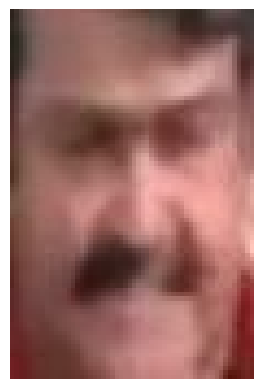

In [ ]:
# Displaying any random movie character along with age group
#np.random.seed(10)
idx = np.random.choice(train.index)
img_name = train.ID[idx]
img = imageio.imread(os.path.join('/content/Train', img_name))

print('Age group:', train.Class[idx])
plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
temp = []
for img_name in train.ID:
    img_path = os.path.join('/content/Train', img_name)
    img = imageio.imread(img_path)
    img = np.array(Image.fromarray(img).resize((32, 32))).astype('float32')
    temp.append(img)
train_x = np.stack(temp)


/tmp/ipykernel_3790/570228560.py:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(img_path)


In [ ]:
temp = []
for img_name in test.ID:
    img_path = os.path.join('/content/Test', img_name)
    img = imageio.imread(img_path)
    img = np.array(Image.fromarray(img).resize((32, 32))).astype('float32')
    temp.append(img)
test_x = np.stack(temp)


/tmp/ipykernel_3790/1505235615.py:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(img_path)


In [ ]:
# Normalizing the images
train_x = train_x / 255.
test_x = test_x / 255.
# Encoding the categorical variable to numeric
lb = LabelEncoder()
train_y = lb.fit_transform(train.Class)
train_y = keras.utils.to_categorical(train_y)


In [ ]:
# Specifying all the parameters we will be using in our network
input_num_units = (32, 32, 3)
hidden_num_units = 500
output_num_units = 3
epochs = 5
batch_size = 128


In [ ]:
model = Sequential([
  InputLayer(input_shape=input_num_units),
  Flatten(),
  Dense(units=hidden_num_units, activation='relu'),
  Dense(units=output_num_units, activation='softmax'),
])
# Printing model summary
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500)            │     1,536,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,503 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,538,003 (5.87 MB)

 Trainable params: 1,538,003 (5.87 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compiling and Training Network
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_x, train_y, batch_size=batch_size, epochs=epochs, verbose=1)


Epoch 1/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.5780 - loss: 0.8995
Epoch 2/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.6036 - loss: 0.8499
Epoch 3/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.6162 - loss: 0.8282
Epoch 4/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.6262 - loss: 0.8166
Epoch 5/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.6248 - loss: 0.8105


In [ ]:
# Training model along with validation data
# Training model along with validation data
model.fit(train_x, train_y, batch_size=batch_size, epochs=epochs, verbose=1, validation_split=0.2)


Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.6309 - loss: 0.8044 - val_accuracy: 0.6386 - val_loss: 0.7879
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.6334 - loss: 0.7992 - val_accuracy: 0.6361 - val_loss: 0.7980
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.6386 - loss: 0.7933 - val_accuracy: 0.6399 - val_loss: 0.7821
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.6420 - loss: 0.7880 - val_accuracy: 0.6256 - val_loss: 0.8025
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.6437 - loss: 0.7814 - val_accuracy: 0.6241 - val_loss: 0.8134


In [ ]:
# Predicting and importing the result in a csv file
pred = model.predict(test_x)
pred = np.argmax(pred, axis=1)
pred = lb.inverse_transform(pred)
test['Class'] = pred
test.to_csv('out.csv', index=False)


208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


/tmp/ipykernel_3790/1282981371.py:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(os.path.join('/content/Test', img_name))


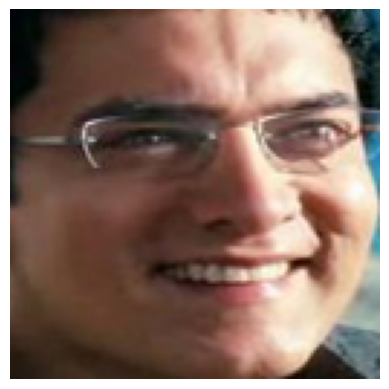

AttributeError: 'Sequential' object has no attribute 'predict_classes'

In [ ]:
# Visual Inspection of predictions
idx = 2481
img_name = test.ID[idx]
img = imageio.imread(os.path.join('/content/Test', img_name))
plt.imshow(np.array(Image.fromarray(img).resize((128, 128))))
plt.axis('off')
plt.show()
pred = model.predict_classes(test_x)
single_pred_index = np.argmax(pred_probabilities[idx])
print('Original:', train.Class[idx], 'Predicted:', lb.inverse_transform([single_pred_index])[0])


/tmp/ipykernel_3790/2867209616.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(os.path.join('/content/Test', img_name))


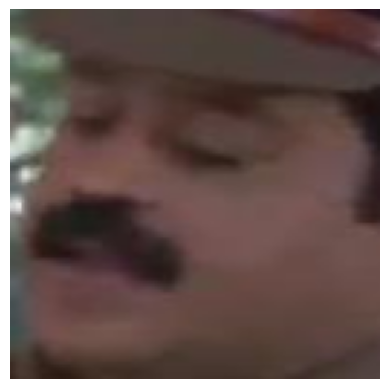

208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Original: YOUNG Predicted: MIDDLE


In [ ]:
# Visual Inspection of predictions
idx = 2367
img_name = test.ID[idx]

# Read and show the image
img = imageio.imread(os.path.join('/content/Test', img_name))
plt.imshow(np.array(Image.fromarray(img).resize((128, 128))))
plt.axis('off')
plt.show()

# 1. Calculate the predictions for the test set
pred_probabilities = model.predict(test_x)

# 2. Get the index of the highest probability class
pred = np.argmax(pred_probabilities, axis=1)

# 3. Print the comparison
print('Original:', train.Class[idx], 'Predicted:', lb.inverse_transform([pred[idx]])[0])